In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
x_data = np.array([0.119, 0.718, 1.324, 2.859, 3.948])
y_data = np.array([-0.572, -2.015, -3.342, -6.752, -6.742])
n = len(x_data) - 1

x_data, y_data

(array([0.119, 0.718, 1.324, 2.859, 3.948]),
 array([-0.572, -2.015, -3.342, -6.752, -6.742]))

In [19]:
def lagrange_basis(i, x, x_nodes):
    result = 1.0
    for j in range(len(x_nodes)):
        if j != i:
            result *= (x - x_nodes[j]) / (x_nodes[i] - x_nodes[j])
    return result

In [20]:
def lagrange_polynomial(x, x_nodes, y_nodes):
    if np.isscalar(x):
        result = 0.0
        for i in range(len(y_nodes)):
            result += y_nodes[i] * lagrange_basis(i, x, x_nodes)
        return result
    else:
        return np.array([lagrange_polynomial(xi, x_nodes, y_nodes) for xi in x])

In [21]:
x1, x2 = x_data[1], x_data[2]
x_eval = x1 + x2
L4_value = lagrange_polynomial(x_eval, x_data, y_data)

f"L4(x1 + x2) = {L4_value:.6f}"

'L4(x1 + x2) = -5.005028'

In [22]:
x_plot = np.linspace(min(x_data) - 0.5, max(x_data) + 0.5, 500)
y_lagrange = np.array([lagrange_polynomial(xi, x_data, y_data) for xi in x_plot])

y_lagrange[:10]

array([1.06898963, 1.03082599, 0.99296959, 0.95541689, 0.91816441,
       0.88120866, 0.84454617, 0.80817351, 0.77208724, 0.73628397])

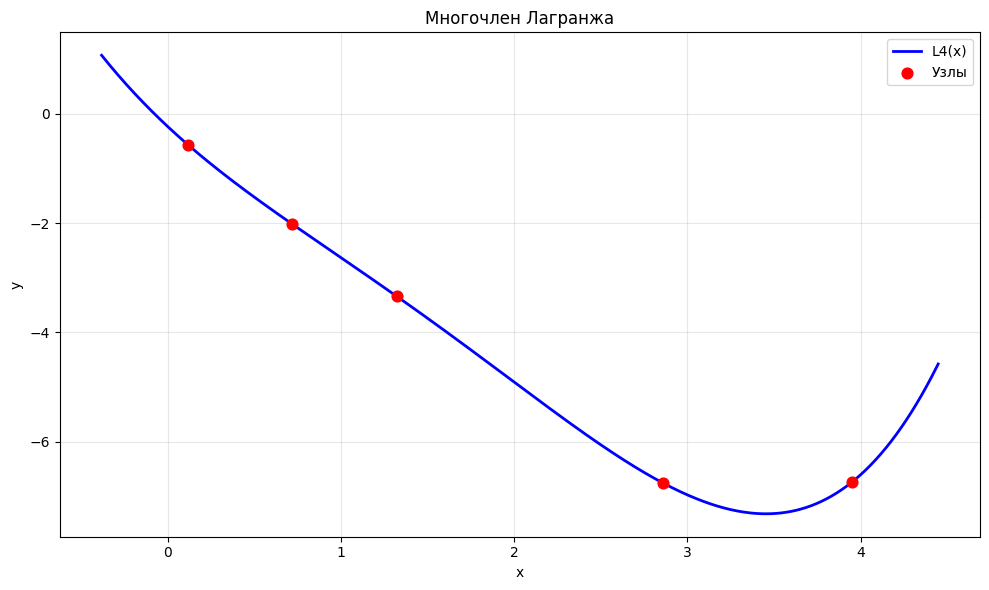

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_lagrange, label='L4(x)', color='blue', linewidth=2)
plt.scatter(x_data, y_data, color='red', label='Узлы', zorder=5, s=60)
plt.xlabel('x'); plt.ylabel('y')
plt.title('Многочлен Лагранжа')
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.show()

In [24]:
def build_finite_differences(y):
    table = [np.array(y, dtype=float)]
    for level in range(1, len(y)):
        prev = table[-1]
        curr = np.array([prev[i+1] - prev[i] for i in range(len(prev)-1)])
        table.append(curr)
    return table

In [25]:
def build_divided_differences(x, y):
    n = len(x)
    table = np.zeros((n, n))
    table[:, 0] = y
    for j in range(1, n):
        for i in range(n - j):
            table[i, j] = (table[i+1, j-1] - table[i, j-1]) / (x[i+j] - x[i])
    return table

In [26]:
finite_diff = build_finite_differences(y_data)
divided_diff = build_divided_differences(x_data, y_data)

In [46]:
print("Конечные разности:\n")
print(f"{'xk':>8} {'yk':>10} {'d1':>9} {'d2':>9} {'d3':>9} {'d4':>9}")

for i in range(len(x_data)):
    row = f"{x_data[i]:8.3f} {y_data[i]:10.3f}"
    for level in range(1, len(finite_diff)):
        if i < len(finite_diff[level]):
            row += f" {finite_diff[level][i]:9.4f}"
        else:
            row += " " * 10
    print(row)

Конечные разности:

      xk         yk        d1        d2        d3        d4
   0.119     -0.572   -1.4430    0.1160   -2.1990    7.7020
   0.718     -2.015   -1.3270   -2.0830    5.5030          
   1.324     -3.342   -3.4100    3.4200                    
   2.859     -6.752    0.0100                              
   3.948     -6.742                                        


In [47]:
print("Раздённые разности:\n")
print(f"{'xk':>8} {'yk':>10} {'1-го':>9} {'2-го':>9} {'3-го':>9} {'4-го':>9}")

for i in range(len(x_data)):
    row = f"{x_data[i]:8.3f} {y_data[i]:10.3f}"
    for j in range(1, min(5, len(x_data) - i)):
        row += f" {divided_diff[i, j]:9.4f}"
    print(row)

Раздённые разности:

      xk         yk      1-го      2-го      3-го      4-го
   0.119     -0.572   -2.4090    0.1819   -0.0718    0.0887
   0.718     -2.015   -2.1898   -0.0148    0.2678
   1.324     -3.342   -2.2215    0.8501
   2.859     -6.752    0.0092
   3.948     -6.742


In [29]:
def newton_polynomial(x, x_nodes, divided_diff):
    if np.isscalar(x):
        result = divided_diff[0, 0]
        product = 1.0
        for j in range(1, len(x_nodes)):
            product *= (x - x_nodes[j-1])
            result += divided_diff[0, j] * product
        return result
    else:
        return np.array([newton_polynomial(xi, x_nodes, divided_diff) for xi in x])

In [48]:
N4_value = newton_polynomial(x_eval, x_data, divided_diff)

f"N4(x1 + x2) = {N4_value:.6f}"

'N4(x1 + x2) = -5.005028'

In [31]:
y_newton = np.array([newton_polynomial(xi, x_data, divided_diff) for xi in x_plot])

y_newton[:10]

array([1.06898963, 1.03082599, 0.99296959, 0.95541689, 0.91816441,
       0.88120866, 0.84454617, 0.80817351, 0.77208724, 0.73628397])

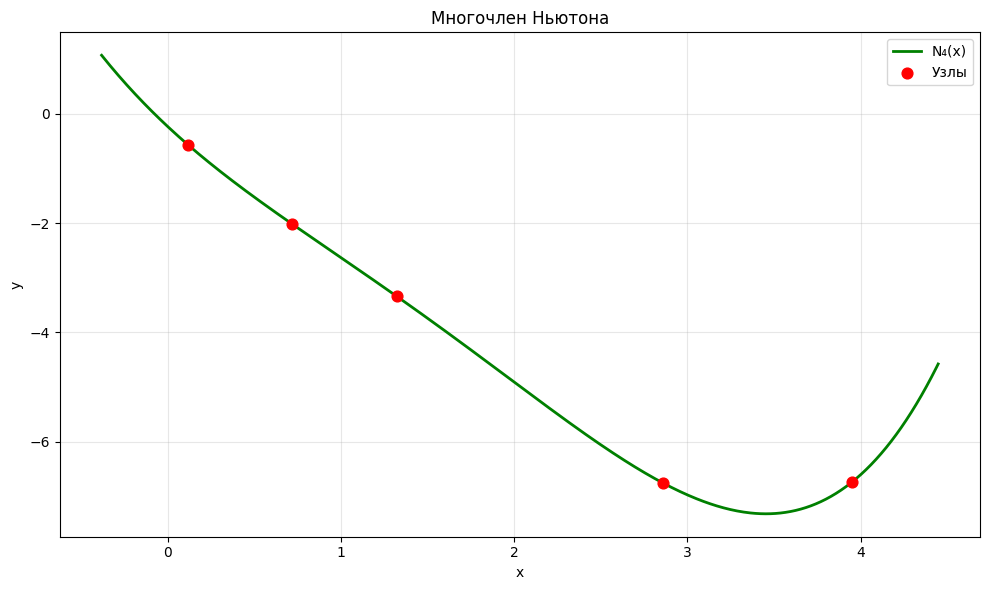

In [32]:
plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_newton, label='N₄(x)', color='green', linewidth=2)
plt.scatter(x_data, y_data, color='red', label='Узлы', zorder=5, s=60)
plt.xlabel('x'); plt.ylabel('y')
plt.title('Многочлен Ньютона')
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.show()

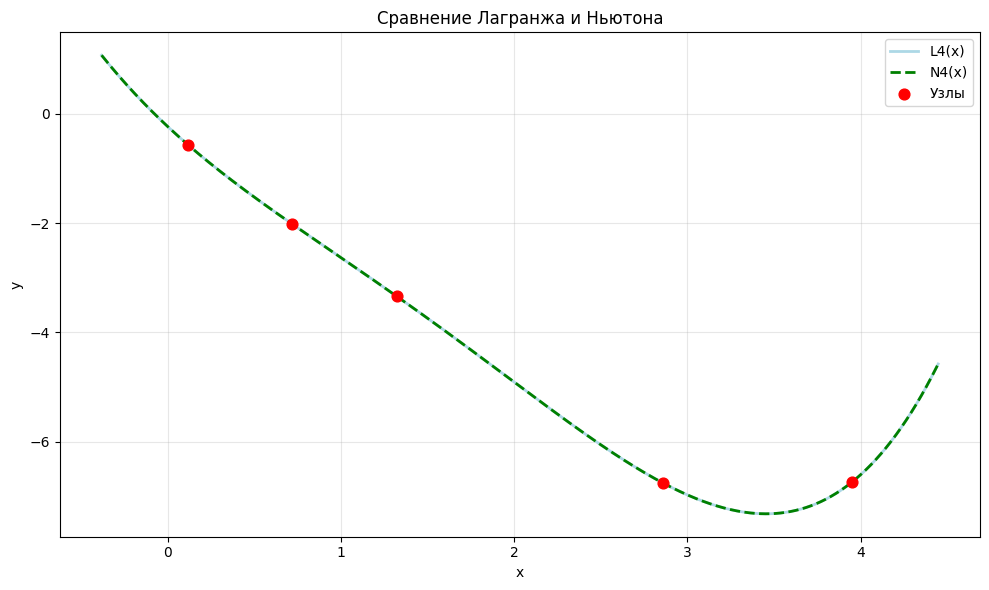

In [52]:
plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_lagrange, label='L4(x)', color='lightblue', linewidth=2)
plt.plot(x_plot, y_newton, label='N4(x)', color='green', linestyle='--', linewidth=2)
plt.scatter(x_data, y_data, color='red', label='Узлы', zorder=5, s=60)
plt.xlabel('x'); plt.ylabel('y')
plt.title('Сравнение Лагранжа и Ньютона')
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.show()

In [34]:
def linear_spline(x, x_nodes, y_nodes):
    if np.isscalar(x):
        for i in range(len(x_nodes) - 1):
            if x_nodes[i] <= x <= x_nodes[i+1]:
                t = (x - x_nodes[i]) / (x_nodes[i+1] - x_nodes[i])
                return y_nodes[i] + t * (y_nodes[i+1] - y_nodes[i])
        i = 0 if x < x_nodes[0] else len(x_nodes) - 2
        t = (x - x_nodes[i]) / (x_nodes[i+1] - x_nodes[i])
        return y_nodes[i] + t * (y_nodes[i+1] - y_nodes[i])
    else:
        return np.array([linear_spline(xi, x_nodes, y_nodes) for xi in x])

In [35]:
y_linear = np.array([linear_spline(xi, x_data, y_data) for xi in x_plot])

y_linear[:10]

array([0.63250751, 0.60919462, 0.58588173, 0.56256883, 0.53925594,
       0.51594305, 0.49263016, 0.46931726, 0.44600437, 0.42269148])

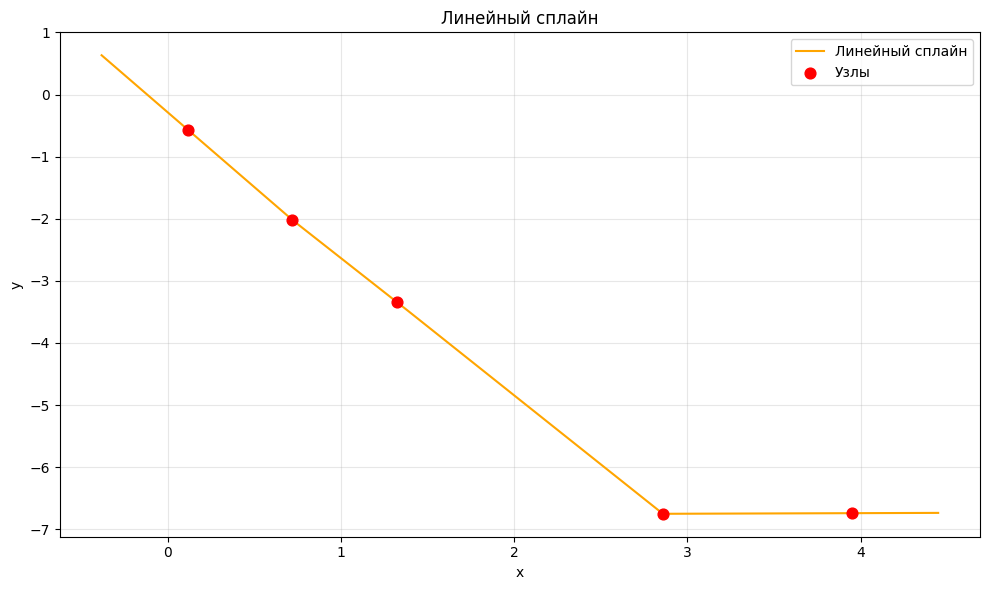

In [36]:
plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_linear, label='Линейный сплайн', color='orange', linewidth=1.5)
plt.scatter(x_data, y_data, color='red', label='Узлы', zorder=5, s=60)
plt.xlabel('x'); plt.ylabel('y')
plt.title('Линейный сплайн')
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.show()

In [37]:
def build_quadratic_splines(x_nodes, y_nodes):
    n_intervals = len(x_nodes) - 1
    coefficients = []
    for i in range(n_intervals):
        if i < n_intervals - 1:
            idx = [i, i+1, i+2]
        else:
            idx = [i-1, i, i+1]
        X = np.array([[x_nodes[k]**2, x_nodes[k], 1] for k in idx])
        Y = np.array([y_nodes[k] for k in idx])
        a, b, c = np.linalg.solve(X, Y)
        coefficients.append((a, b, c))
    return coefficients

In [38]:
def quadratic_spline(x, x_nodes, coefficients):
    if np.isscalar(x):
        for i in range(len(x_nodes) - 1):
            if x_nodes[i] <= x <= x_nodes[i+1]:
                a, b, c = coefficients[i]
                return a * x**2 + b * x + c
        a, b, c = coefficients[0] if x < x_nodes[0] else coefficients[-1]
        return a * x**2 + b * x + c
    else:
        return np.array([quadratic_spline(xi, x_nodes, coefficients) for xi in x])

In [39]:
quad_coeffs = build_quadratic_splines(x_data, y_data)
y_quad = np.array([quadratic_spline(xi, x_data, quad_coeffs) for xi in x_plot])

y_quad[:10]

array([0.73248735, 0.70637603, 0.6802988 , 0.65425564, 0.62824656,
       0.60227156, 0.57633064, 0.55042379, 0.52455103, 0.49871235])

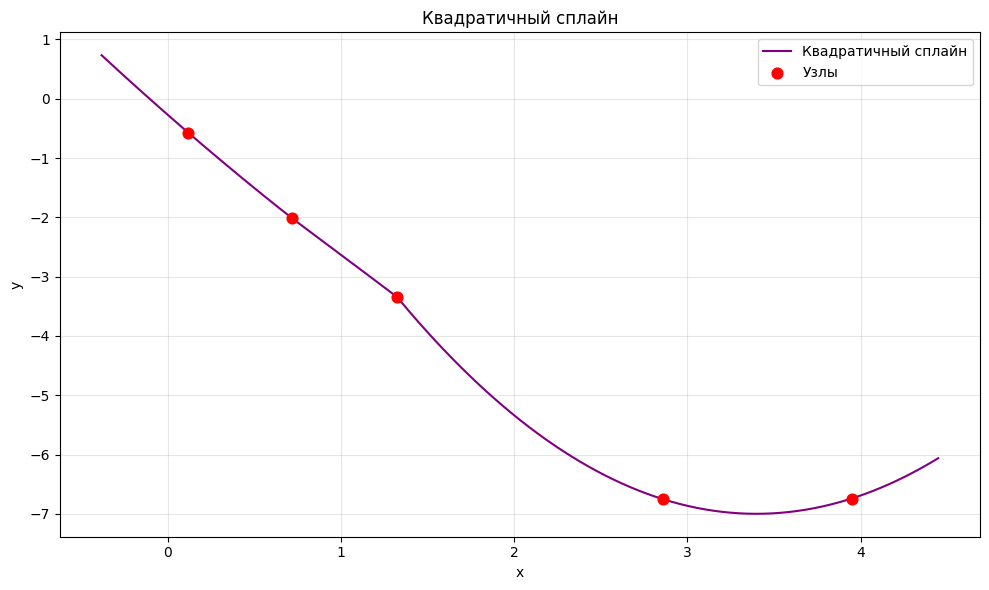

In [40]:
plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_quad, label='Квадратичный сплайн', color='purple', linewidth=1.5)
plt.scatter(x_data, y_data, color='red', label='Узлы', zorder=5, s=60)
plt.xlabel('x'); plt.ylabel('y')
plt.title('Квадратичный сплайн')
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.show()

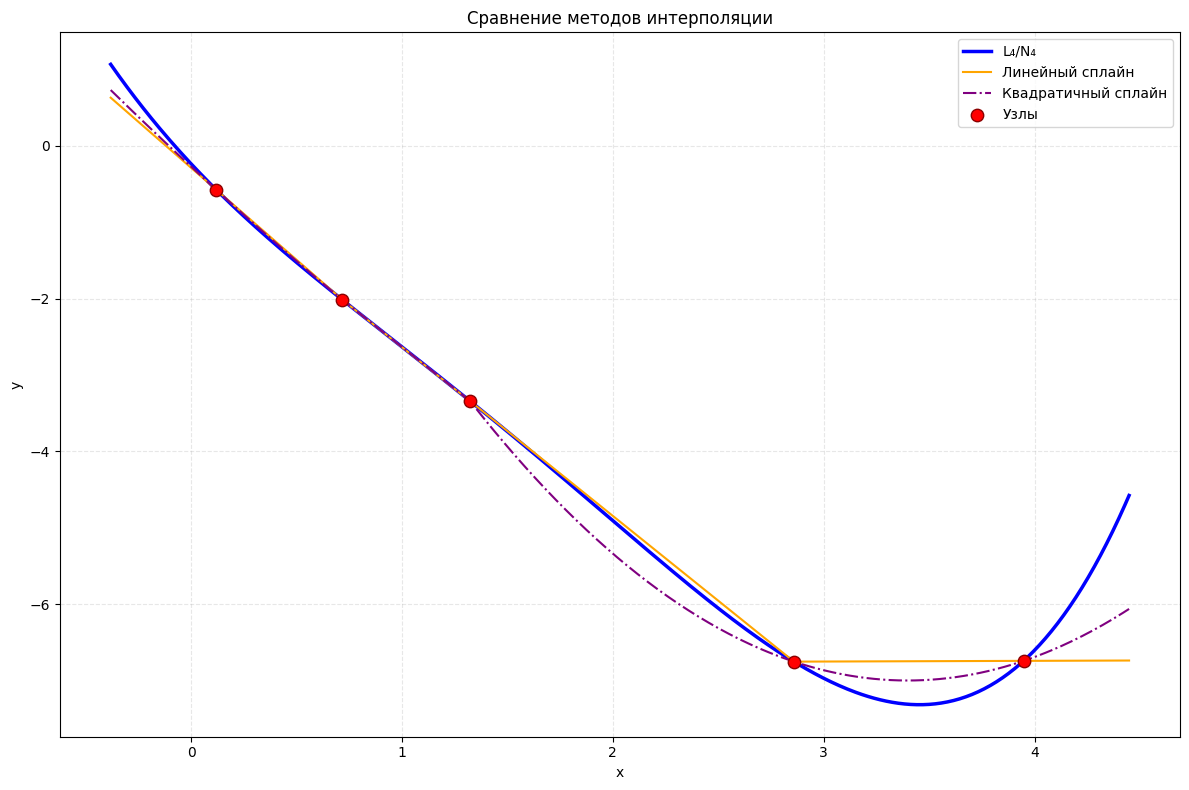

In [53]:
plt.figure(figsize=(12, 8))
plt.plot(x_plot, y_lagrange, label='L₄/N₄', color='blue', linewidth=2.5)
plt.plot(x_plot, y_linear, label='Линейный сплайн', color='orange', linestyle='-', linewidth=1.5)
plt.plot(x_plot, y_quad, label='Квадратичный сплайн', color='purple', linestyle='-.', linewidth=1.5)
plt.scatter(x_data, y_data, color='red', label='Узлы', zorder=5, s=80, edgecolors='darkred')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Сравнение методов интерполяции')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=10, loc='best')
plt.tight_layout()
plt.show()